# Comparação entre IA e pipeline matemático

## Objetivo

Compara os resultados do pipeline matemático com os métodos de IA usando somente exames presentes nas duas fontes.

In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent,
    NOTEBOOK_CWD.parent.parent,
):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.project.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment()


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from utils.project.notebook_env import get_default_split_paths
import utils.comparison_utils as cmp
import utils.visualization as viz

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
        "savefig.dpi": 300,
    },
)
plt.close("all")

SPLIT_PATHS_BY_RESOLUTION = get_default_split_paths(REPO_ROOT)
VALID_SPLITS = ("train", "val", "test")


## Configuração

Ajuste nesta seção apenas os parâmetros da análise; o pipeline base não é alterado.

## Carregamento de dados

### Dados para comparação com métodos de IA

In [3]:
IA_RESULTS_BASE = REPO_ROOT / "output/ia_results"
MATH_TEST_SUMMARY_PATHS = {
    resolution: {
        split_name: split_path / f"ostios_{split_name}_summary.csv"
        for split_name, split_path in split_paths.items()
        if split_name in VALID_SPLITS
    }
    for resolution, split_paths in SPLIT_PATHS_BY_RESOLUTION.items()
}

ia_results_df, missing_ia_files = cmp.load_ia_results_for_comparison(IA_RESULTS_BASE)
math_results_df, missing_math_files = cmp.load_math_results_for_comparison(MATH_TEST_SUMMARY_PATHS)
comparison_raw_df = pd.concat([ia_results_df, math_results_df], ignore_index=True)
comparison_common_df = cmp.filter_to_common_ia_math_ids(comparison_raw_df)
comparison_agg_df = cmp.build_comparison_agg_df(comparison_common_df)
common_ids_by_resolution = (
    cmp.get_common_ia_math_keys(comparison_raw_df)
    .groupby("target_resolution")["img_id"]
    .nunique()
)

print("Shapes carregados para comparação IA:")
print("- IA bruto:", ia_results_df.shape)
print("- Matemático bruto:", math_results_df.shape)
print("- Consolidado bruto:", comparison_raw_df.shape)
print("- Consolidado com IDs comuns:", comparison_common_df.shape)
print("- Agregado:", comparison_agg_df.shape)
print("\nIDs comuns IA x Matemático por resolução:")
print(common_ids_by_resolution)

if missing_ia_files:
    print("\nAvisos IA:")
    for msg in missing_ia_files:
        print("-", msg)

if missing_math_files:
    print("\nAvisos Matemático:")
    for msg in missing_math_files:
        print("-", msg)


Shapes carregados para comparação IA:
- IA bruto: (1400, 7)
- Matemático bruto: (1300, 7)
- Consolidado bruto: (2700, 7)
- Consolidado com IDs comuns: (1338, 7)
- Agregado: (9, 12)

IDs comuns IA x Matemático por resolução:
target_resolution
high_res     46
mid_res     200
Name: img_id, dtype: int64


## Análise

As subseções abaixo apresentam as métricas, tabelas ou visualizações do objetivo definido.

## Comparação: Métodos de IA vs Método Matemático

In [4]:
def display_comparison_scenario(
    scenario_label,
    scenario_math_df,
    scenario_ia_df,
    scenario_missing_math_files,
    resolution,
):
    scenario_raw_df = pd.concat([scenario_ia_df, scenario_math_df], ignore_index=True)
    scenario_agg_df = cmp.build_comparison_agg_df(scenario_raw_df)

    if scenario_agg_df.empty:
        viz.plot_comparison_bar_by_resolution(
            scenario_agg_df,
            resolution,
            comparison_title=scenario_label,
        )
        return

    viz.plot_comparison_bar_by_resolution(
        scenario_agg_df,
        resolution,
        comparison_title=scenario_label,
    )

### 1. Conjunto completo de dados

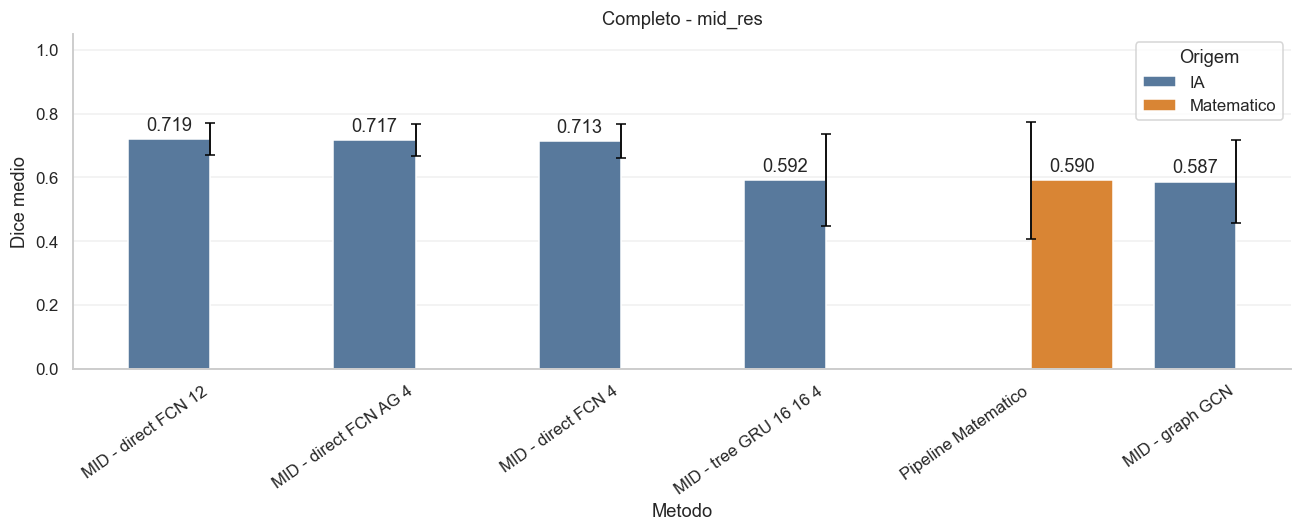

In [5]:
full_ia_df, full_math_df, full_missing_math_files = cmp.load_ostia_comparison_scenario(
    ia_results_df,
    MATH_TEST_SUMMARY_PATHS,
    "full",
)
display_comparison_scenario(
    "Completo",
    full_math_df,
    full_ia_df,
    full_missing_math_files,
    "mid_res",
)

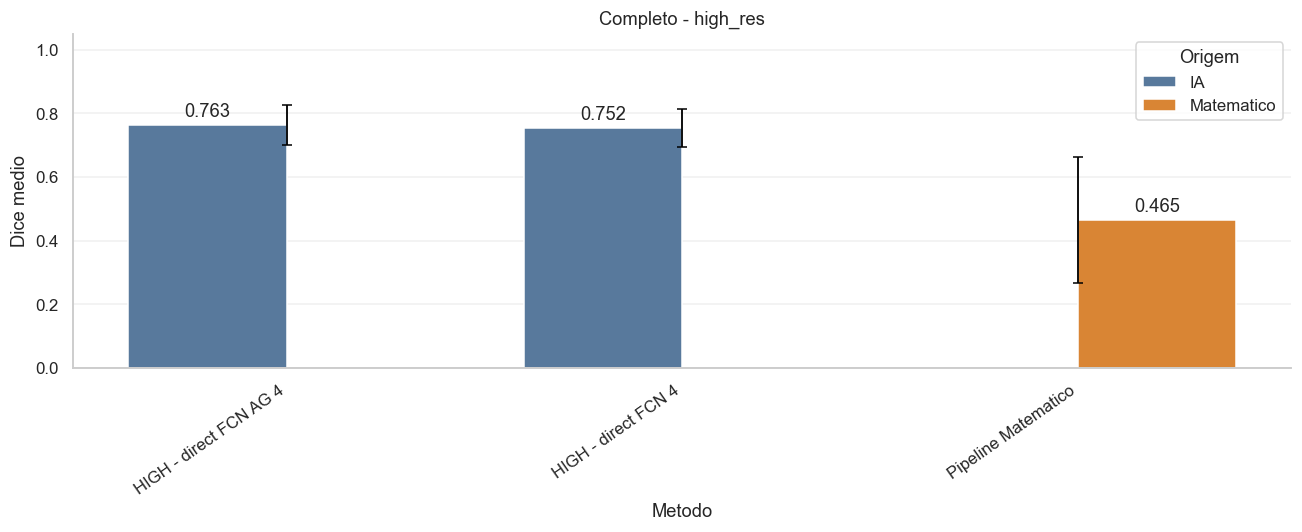

In [6]:
display_comparison_scenario(
    "Completo",
    full_math_df,
    full_ia_df,
    full_missing_math_files,
    "high_res",
)

### 2. Apenas casos em que os óstios são encontrados corretamente

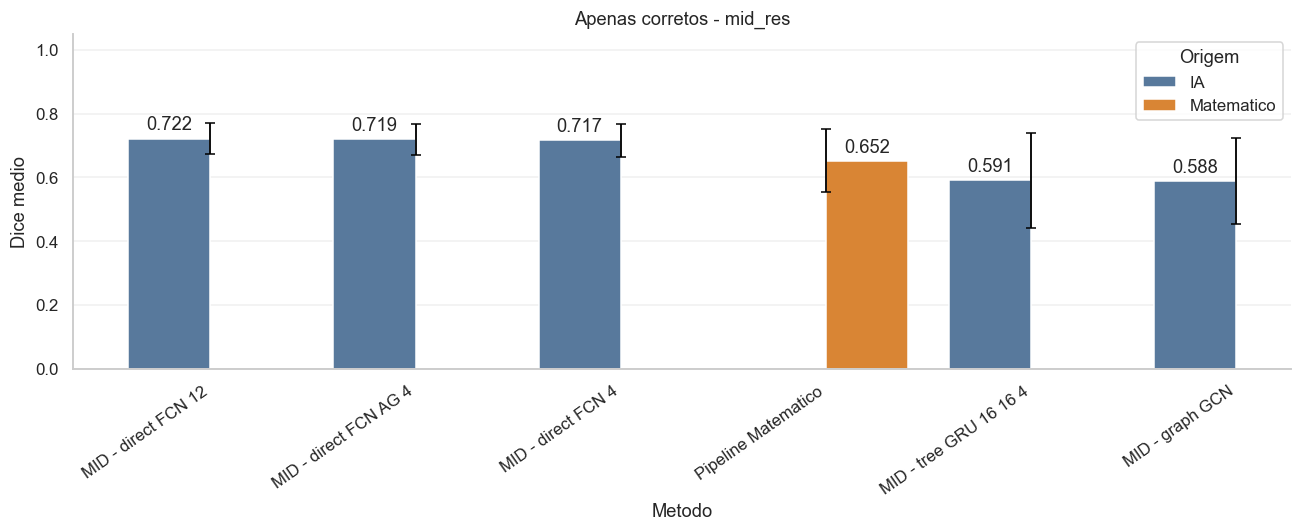

In [7]:
correct_ia_df, correct_math_df, correct_missing_math_files = cmp.load_ostia_comparison_scenario(
    ia_results_df,
    MATH_TEST_SUMMARY_PATHS,
    "correct",
)
display_comparison_scenario(
    "Apenas corretos",
    correct_math_df,
    correct_ia_df,
    correct_missing_math_files,
    "mid_res",
)

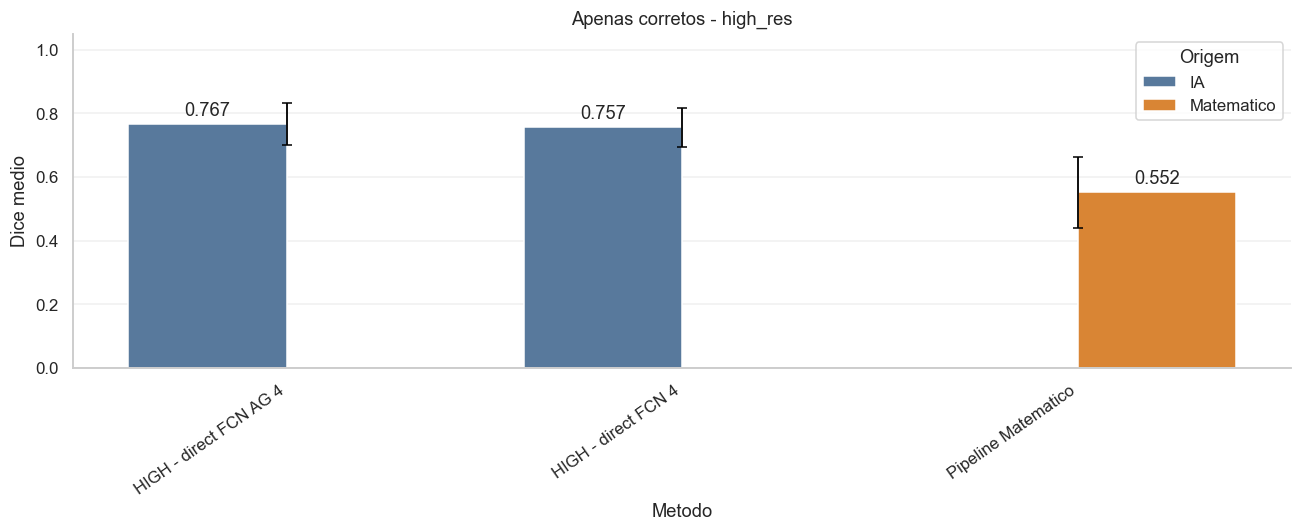

In [8]:
display_comparison_scenario(
    "Apenas corretos",
    correct_math_df,
    correct_ia_df,
    correct_missing_math_files,
    "high_res",
)

### 3. Apenas casos em que os óstios não são encontrados corretamente

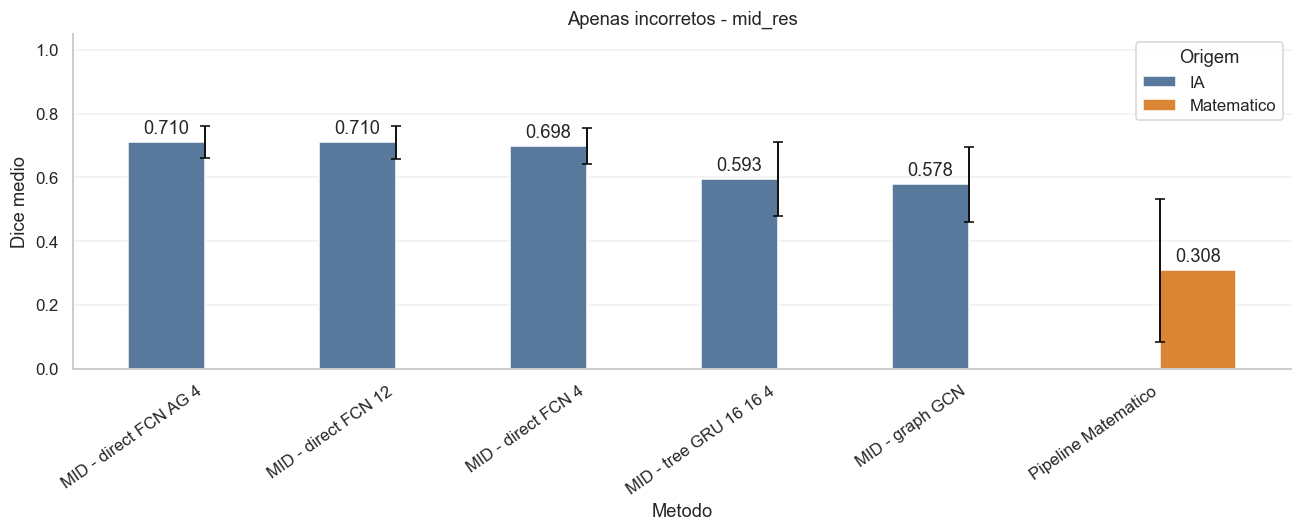

In [9]:
incorrect_ia_df, incorrect_math_df, incorrect_missing_math_files = cmp.load_ostia_comparison_scenario(
    ia_results_df,
    MATH_TEST_SUMMARY_PATHS,
    "incorrect",
)
display_comparison_scenario(
    "Apenas incorretos",
    incorrect_math_df,
    incorrect_ia_df,
    incorrect_missing_math_files,
    "mid_res",
)

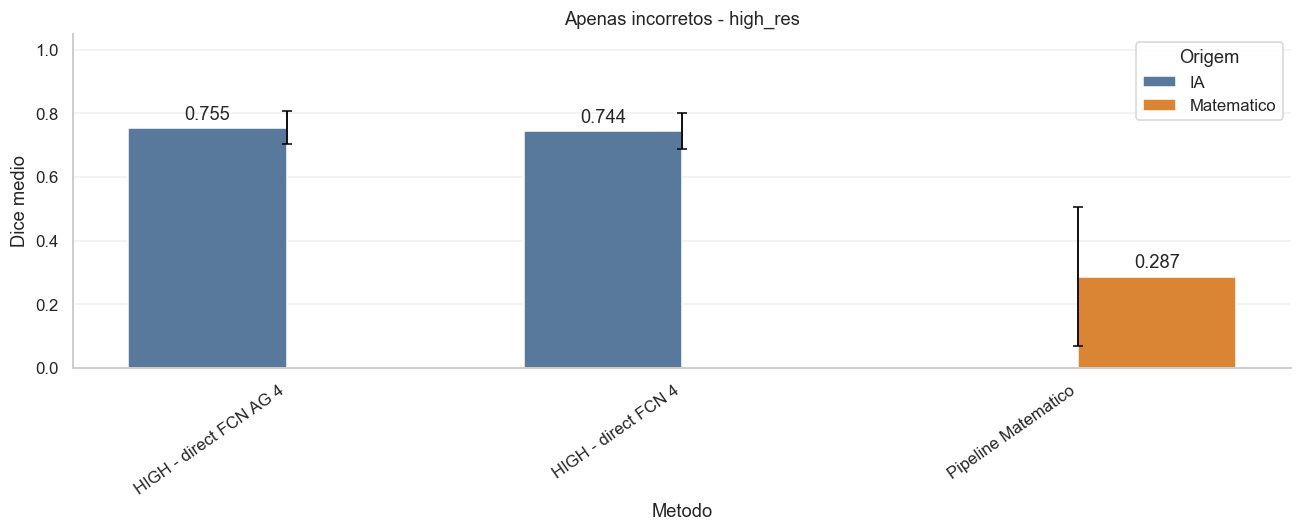

In [10]:
display_comparison_scenario(
    "Apenas incorretos",
    incorrect_math_df,
    incorrect_ia_df,
    incorrect_missing_math_files,
    "high_res",
)

## Comparação por imagem interativa: IA vs método matemático

Abaixo os gráficos interativos separados por cenário e resolução. Cada método de IA é apresentado como uma série independente, sem selecionar o melhor método por exame. Passe o mouse sobre os pontos para ver `img_id`, Dice e método.

### Completo

In [11]:
# Completo - Mid Res
scenario_image_df = cmp.build_ostia_image_comparison_df(full_ia_df, full_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Completo")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Completo")

In [12]:
# Completo - High Res
scenario_image_df = cmp.build_ostia_image_comparison_df(full_ia_df, full_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "high_res", comparison_title="Completo")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "high_res", comparison_title="Completo")

### Apenas corretos

In [13]:
# Apenas corretos - Mid Res
scenario_image_df = cmp.build_ostia_image_comparison_df(correct_ia_df, correct_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas corretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas corretos")

In [14]:
# Apenas corretos - High Res
scenario_image_df = cmp.build_ostia_image_comparison_df(correct_ia_df, correct_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas corretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas corretos")

### Apenas incorretos

In [15]:
# Apenas incorretos - Mid Res
scenario_image_df = cmp.build_ostia_image_comparison_df(incorrect_ia_df, incorrect_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas incorretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "mid_res", comparison_title="Apenas incorretos")

In [16]:
# Apenas incorretos - High Res
scenario_image_df = cmp.build_ostia_image_comparison_df(incorrect_ia_df, incorrect_math_df)
viz.plot_image_dice_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas incorretos")
viz.plot_ia_vs_math_scatter_interactive(scenario_image_df, "high_res", comparison_title="Apenas incorretos")